# SRIP2025 2.0

### Imports and Global Variables

In [1]:
import cv2, logging # For video processing and logging
from ultralytics import YOLO # For detecting vehicles, plates etc.
from deep_sort_realtime.deepsort_tracker import DeepSort # For tracking vehicles using DeepSORT tracker
import matplotlib.pyplot as plt
from IPython.display import clear_output
import re # For text processing (cleaning OCR results)
import pytesseract # For OCR
import pandas as pd # For data manipulation and exporting results

# Initialize YOLOv8 model (for vehicle detection)
model = YOLO("yolov8n.pt")

# Paths to custom models
licol = r"C:\Users\afzal\Downloads\VehicleIVideos\SeniorWork\License Plate color model\best.pt"
carcol = r"C:\Users\afzal\Downloads\VehicleIVideos\SeniorWork\Car color model\best.pt"
logomod = r"C:\Users\afzal\Downloads\VehicleIVideos\SeniorWork\Logo model\best.pt"

# Initialize DeepSORT trackers
tracker1 = DeepSort(max_age=30) # For toll gate 1
tracker2 = DeepSort(max_age=30) # For toll gate 2

# Unified vehicle info for each toll gate
vehicle_db = {1: [], 2: []} # Dictionary with 2 keys: 1 (toll gate 1) and 2 (toll gate 2), each value is a list to store vehicle info

# Configure logging
logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename=r"C:\Users\afzal\Downloads\VehicleIVideos\app2.log",
    filemode='a',
    encoding='utf-8'
)
logger = logging.getLogger()
level_int = logger.getEffectiveLevel()
logging_level_name = logging.getLevelName(level_int)
print(f"Logging level: {logging_level_name}")


c:\Users\afzal\AppData\Local\Programs\Python\Python312\Lib\site-packages\deep_sort_realtime\embedder\embedder_pytorch.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Logging level: DEBUG


In [26]:
#testing
print(vehicle_db)

{1: [], 2: []}


### Helper Functions for Feature Extraction

In [2]:
def clean_text(text):   # Removes non-alphanumeric characters from input text
    return re.sub(r'[^a-zA-Z0-9]', '', text)

def process_ocr_text(ocr_text): # Converts OCR output to uppercase and cleans it
    return clean_text(ocr_text.upper())

def get_valid_plate_number(plate_text): # Checks for valid plate format
    match = re.search(r'^[A-Z]{2}\d{2}[A-Z]{2}\d{4}$', plate_text)
    return match.group(0) if match else ""

def crop_and_display_license_plate(image, license_plate_box):
    x1, y1, x2, y2 = [int(coord) for coord in license_plate_box]    # Extracts bounding box coordinates from input image
    license_plate_image = image[y1:y2, x1:x2]   # Crops license plate from image
    model_lp = YOLO(licol)  # Loads license plate color model
    results = model_lp.predict(license_plate_image, conf=0.5)
    top1_class_idx = results[0].probs.top1 # Runs classification on cropped plate image
    best_classification = results[0].names[top1_class_idx] # Predicted color class 
    tesseract_text = pytesseract.image_to_string(license_plate_image, config='--psm 7') # Runs OCR on cropped plate image
    ocr_text = process_ocr_text(tesseract_text) 
    plate_number = get_valid_plate_number(ocr_text)
    return {
        'text': plate_number or ocr_text,   # Returns cleaned plate number or OCR text
        'color': best_classification    # Predicted plate color
    }

def crop_car(image, car_box): # Car detection and classification
    x1, y1, x2, y2 = [int(coord) for coord in car_box]  # Extracts bounding box coordinates
    car_image = image[y1:y2, x1:x2]
    model_car = YOLO(carcol)
    results = model_car.predict(car_image, conf=0.5)
    if results and len(results) > 0:
        results = results[0]
        class_idx = int(results.boxes.cls[0])
        class_name = results.names[class_idx]
        return class_name
    return "unknown"

def crop_logo(image, logo_box): # Manufacturer logo detection
    x1, y1, x2, y2 = [int(coord) for coord in logo_box]
    logo_image = image[y1:y2, x1:x2]
    model_logo = YOLO(logomod)
    results = model_logo.predict(logo_image, conf=0.5)
    top1_class_idx = results[0].probs.top1
    best_classification = results[0].names[top1_class_idx]
    return best_classification

### Main Video Processing Function

In [ ]:
def process_video(video_path, tracker, toll_gate=1):    # Processes video for vehicle detection and tracking
    logging.info(f"Starting video processing for Toll Gate {toll_gate} - {video_path}...")
    logging.debug(f"Starting video processing for Toll Gate {toll_gate} - {video_path}...")
    cap = cv2.VideoCapture(video_path)
    fig = plt.figure(figsize=(10, 6))

    while cap.isOpened():   # Reads video frame by frame
        ret, frame = cap.read()
        if not ret:
            break

        model_main = YOLO(r"C:\Users\afzal\Downloads\VehicleIVideos\SeniorWork\best.pt")        # Loads YOLO model and runs detection on current frame
        CONFIDENCE_THRESHOLD = 0.4
        results = model_main(frame, conf=CONFIDENCE_THRESHOLD)
        if isinstance(results, list):
            results = results[0]    # Takes 1st result if multiple detections returned
        names_dict = results.names  # Names of detected classes
        boxes = results.boxes.xyxy.tolist() if results.boxes is not None else []    # List of bounding boxes for detected objects
        class_labels = results.boxes.cls.tolist() if results.boxes is not None else []  # List of class labels for detected boxes

        detections = [] # List to store relevant vehicle detections
        for i, box in enumerate(boxes): 
            class_idx = int(class_labels[i])
            class_name = names_dict[class_idx]
            conf = float(results.boxes.conf[i])
            #logging.debug(f"Detected {class_name} with confidence {conf} at box {box}")
            if class_name in ["car", "bus", "truck", "motorcycle"] and conf > 0.4:
                x1, y1, x2, y2 = [int(coord) for coord in box]
                detections.append([[x1, y1, x2-x1, y2-y1], conf, class_name])
                logging.debug(f"{class_name} detected at [{x1},{y1},{x2},{y2}]")


        tracks = tracker.update_tracks(detections, frame=frame) # Updates tracker with new detections

        for track in tracks: # Processes each confirmed vehicle track 
            if not track.is_confirmed():
                continue
            track_id = track.track_id
            ltrb = track.to_ltrb()
            x1, y1, x2, y2 = map(int, ltrb)

            # Draws bounding box and ID on frame
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f'ID:{track_id}', (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            logging.debug(f"## 01--Track ID: {track_id}, BBox: [{x1}, {y1}, {x2}, {y2}], fr={frame.shape[1]}")

            # Detects exits (right 15% of frame)
            if x2 > frame.shape[1] * 0.85:
                logging.debug(f"## 02--Vehicle exiting at TG{toll_gate} with ID: {track_id}")
                # Capture timestamp
                current_time = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000

                # License Plate
                plate_info = crop_and_display_license_plate(frame, [x1, y1, x2, y2])
                license_plate = plate_info.get('text', '')
                plate_color = plate_info.get('color', '')
                logging.debug(f"## 03--License Plate: {license_plate}, Color: {plate_color}")

                # Color & Logo
                vehicle_color = crop_car(frame, [x1, y1, x2, y2])
                logo = crop_logo(frame, [x1, y1, x2, y2])
                logging.debug(f"## 04--Vehicle Color: {vehicle_color}, Logo: {logo}")

                # Placeholders for stickers/flags (to be extended)
                stickers = 0
                flags = 0
                vehicle_type = class_name
                logging.debug(f"## 05--Vehicle Type: {vehicle_type}, Stickers: {stickers}, Flags: {flags}")

                vehicle_db[toll_gate].append({
                    'track_id': track_id,
                    'license_plate': license_plate,
                    'plate_color': plate_color,
                    'vehicle_color': vehicle_color,
                    'vehicle_type': vehicle_type,
                    'logo': logo,
                    'stickers': stickers,
                    'flags': flags,
                    'timestamp': current_time,
                    'bbox': [x1, y1, x2, y2],
                    'matched': False,
                    'matched_track_id': None,
                    'enter_time': current_time if toll_gate == 1 else None,
                    'exit_time': current_time if toll_gate == 2 else None,
                    'match_criteria': None,
                    'score': 0.0
                })
                print(f"Vehicles stored for TG{toll_gate}: {len(vehicle_db[toll_gate])}")
                logging.debug(f"Vehicles stored for TG{toll_gate}: {len(vehicle_db[toll_gate])}, License Plate:{license_plate}")
                

        # Real-time visualization
        clear_output(wait=True)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Toll Gate {toll_gate} Monitoring')
        plt.show()
        plt.pause(0.001)

    # Cleanup
    cap.release()
    plt.close(fig)
    logging.info(f"Ending video processing for Toll Gate {toll_gate}.")

### Matching and Reporting Functions

In [8]:
def match_by_license_plate(time_window=15):
    logging.info("Starting to match vehicles by license plate...")

    for veh2 in vehicle_db[2]:
        if veh2['license_plate']:
            for veh1 in vehicle_db[1]:  # For every vehicle detected at toll gate 2 (vehicle_db[1]), it searches for a vehicle at toll gate 1 (vehicle_db[2]) with same plate
                if veh1['license_plate'] and veh2['license_plate'] == veh1['license_plate']:
                    time_diff = (veh2['timestamp'] - veh1['timestamp']) / 60
                    if 0 < time_diff <= time_window:    # If time difference is within specified time_window (minutes), match considered
                        veh1['matched'] = True
                        veh1['matched_track_id'] = veh2['track_id']
                        veh1['exit_time'] = veh2['timestamp']
                        veh1['match_criteria'] = 'license_plate'
                        
                        veh2['matched'] = True
                        veh2['matched_track_id'] = veh1['track_id']
                        veh2['enter_time'] = veh1['timestamp']
                        veh2['match_criteria'] = 'license_plate'

                        logging.debug(f"Matched vehicles by license plate: {veh1['license_plate']} at TG1 and {veh2['license_plate']} at TG2")
                        break
    logging.info("Ending to match vehicles by license plate.")



def feature_similarity(veh1, veh2): # Compares both vehicles' features and returns similarity score
    score = 0
    if veh1['vehicle_type'] == veh2['vehicle_type'] and veh1['vehicle_type'] != "unknown":
        score += 0.3
    if veh1['vehicle_color'] == veh2['vehicle_color'] and veh1['vehicle_color'] != "unknown":
        score += 0.2
    if veh1['logo'] == veh2['logo'] and veh1['logo'] != "unknown":
        score += 0.2
    if veh1['stickers'] == veh2['stickers']:
        score += 0.15
    if veh1['flags'] == veh2['flags']:
        score += 0.15
    return score

def match_by_features(time_window=15, threshold=0.7):   # If not matched by license plate, matches vehicles based on features
    logging.info("Starting to match vehicles by features...")
    unmatched_tg1 = [v for v in vehicle_db[1] if not v['matched']]  # Only considers vehicles not matched by license plate
    unmatched_tg2 = [v for v in vehicle_db[2] if not v['matched']]
    for veh2 in unmatched_tg2:
        for veh1 in unmatched_tg1:
            time_diff = (veh2['timestamp'] - veh1['timestamp']) / 60
            if 0 < time_diff <= time_window:
                score = feature_similarity(veh1, veh2)
                if score >= threshold:  # default threshold is 0.7
                    veh1['matched'] = True
                    veh1['matched_track_id'] = veh2['track_id']
                    veh1['exit_time'] = veh2['timestamp']
                    veh1['match_criteria'] = 'features'
                    veh1['score'] = score

                    veh2['matched'] = True
                    veh2['matched_track_id']=veh1['track_id']
                    veh2['enter_time'] = veh1['timestamp']
                    veh2['match_criteria'] = 'features'
                    veh2['score'] = score
                    logging.debug(f"Matched vehicles by features: {veh1['license_plate']} at TG1 and {veh2['license_plate']} at TG2 with score {score}")
                    break
    logging.info("Ending to match vehicles by features.")

def generate_report(file_name):  # Report entry created for each vehicle detected at toll gate 1 (exit time from toll gate 2 also recorded if vehicle is matched)
    logging.info("Generating report...")
    # Export report as Excel
    df = pd.DataFrame(vehicle_db[1])
    df.to_excel(file_name)        
    logging.info(f"Report generated in Excel file {file_name}.")




### Usage Example: Processing, Matching, and Reporting

In [30]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


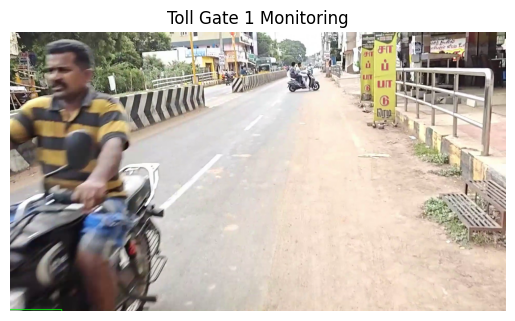

In [12]:
video1 = r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_MultipleVehiclesFront.mp4"
#video2 = r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_MultipleVehicles.mp4"
# Process both videos
process_video(video1, tracker1, toll_gate=1)
#process_video(video1, tracker2, toll_gate=2)

# Run matching
#match_by_license_plate(time_window=15)
#match_by_features(time_window=15, threshold=0.7)
#generate_report('vehicle_report.xlsx')



In [32]:
# Process both videos
process_video(r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_MultipleVehiclesFront.mp4", tracker1, toll_gate=1)
process_video(r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_MultipleVehiclesFront.mp4", tracker2, toll_gate=2)

# Run matching
matches_lp = match_by_license_plate(time_window=15)
matches_feat = match_by_features(time_window=15, threshold=0.7)
report = generate_report()

# Export report as Excel
df = pd.DataFrame(report)
df.to_excel("vehicle_report.xlsx")


KeyboardInterrupt: 

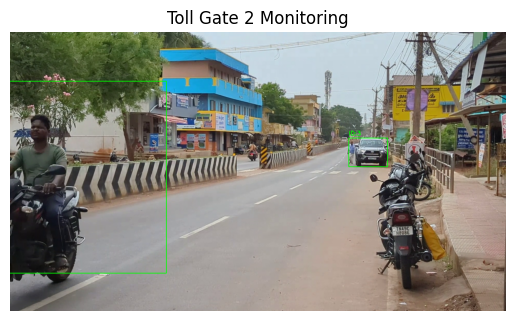

In [ ]:
# Process both videos
process_video(r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_PXL_BikesWhiteCarFront.mp4", tracker1, toll_gate=1)
process_video(r"C:\Users\afzal\Downloads\VehicleIVideos\Tr_PXL_BikesWhiteCarFront.mp4", tracker2, toll_gate=2)

# Run matching
matches_lp = match_by_license_plate(time_window=15)
matches_feat = match_by_features(time_window=15, threshold=0.7)
report = generate_report()

# Export report as Excel
df = pd.DataFrame(report)
df.to_excel("vehicle_report.xlsx")


(Debugging)

In [ ]:
vehicle_db

{1: [], 2: []}

In [ ]:
print(report) # Print report

[]


In [ ]:
print(df)

Empty DataFrame
Columns: []
Index: []
